# Credit Risk Prediction
This notebook follows a practical credit-risk workflow inspired by [A Machine Learning Approach To Credit Risk Assessment](https://towardsdatascience.com/a-machine-learning-approach-to-credit-risk-assessment-ba8eda1cd11f/). The goal is to predict `loan_status`, where 1 represents default and 0 represents no default.

The analysis combines data quality checks, exploratory analysis, categorical encoding, model comparison, probability evaluation, and feature interpretation. Because defaults are the minority class, recall, F1 score, ROC-AUC, and calibration are more informative than accuracy alone.

All analysis, feature engineering, and model decisions in this notebook are my own.

In [61]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import nbformat
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')   

## Import Libraries
NumPy and pandas support data preparation, Plotly and Matplotlib support visual analysis, and scikit-learn/XGBoost provide the modeling and evaluation tools used later.

In [32]:
df = pd.read_csv("data/credit_risk_dataset.csv")

In [33]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## Load the Credit-Risk Dataset
The CSV is loaded into a pandas DataFrame so that data quality, distributions, relationships, and model inputs can be examined consistently throughout the notebook.

## Initial Dataset View
The first rows confirm the dataset contains borrower attributes, loan characteristics, categorical risk indicators, and the binary target `loan_status`. This target is a classification label: `0` means no default and `1` means default.

In [34]:
#Checking for missing values
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

## Missing-Value Check
Employment length has 895 missing values and interest rate has 3,116. Since these fields can carry useful risk information but the missing records are a minority of the dataset, removing incomplete rows follows the article's preprocessing approach.

In [35]:
#Dropping missing values
df = df.dropna(axis=0)

## Remove Incomplete Records
Rows with missing employment length or interest rate are removed before modeling. This keeps the feature matrix complete, although a production workflow should compare this choice with imputation and confirm that missingness is not itself predictive.

In [36]:
print(df.isnull().sum().sum())

0


## Verify Data Completeness
The total missing-value count is `0`, confirming that the cleaned DataFrame is ready for descriptive analysis and model training without incomplete feature rows.

In [37]:
df.shape

(28638, 12)

## Cleaned Dataset Size
This shape check quantifies how much data remains after removing incomplete rows and later provides a baseline for interpreting the train/test sample counts.

In [38]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,28638.000000,2.863800e+04,28638.000000,28638.000000,28638.000000,28638.000000,28638.000000,28638.000000
mean,27.727216,6.664937e+04,4.788672,9656.493121,11.039867,0.216600,0.169488,5.793736
std,6.310441,6.235645e+04,4.154627,6329.683361,3.229372,0.411935,0.106393,4.038483
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.948000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.595600e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.480000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


## Descriptive Statistics
The cleaned data contains 28,638 observations. Extreme maxima such as age 144, employment length 123, and income $6 million are implausible in this context, supporting the article's recommendation to inspect and remove influential outliers.

In [39]:
fig = px.scatter_matrix(
    df,
    dimensions=["person_age","person_income","person_emp_length","loan_amnt","loan_int_rate"],
    labels={
        col: col.replace("_", " ").title()
        for col in df.columns
    },
    height=900,
    color="loan_status"
)

fig.show()

## Multivariate Outlier Exploration
The scatterplot matrix compares major numeric variables and colors observations by default status. It is useful for spotting implausible values and possible separation patterns before fitting models; visual association alone should not be treated as causation.

In [40]:
#Removing outliers
df = df[df["person_age"]<=100]
df = df[df["person_emp_length"]<=100]
df = df[df["person_income"]<= 4000000]

## Remove Implausible Outliers
The filters exclude ages above 100, employment lengths above 100 years, and incomes above $4 million. These rules reduce distortion from clearly unrealistic records, but they should be justified against the institution's real underwriting population before deployment.

In [41]:
#Percentage of non-default cases
data_0 = df[df.loan_status == 0].loan_status.count() / df.loan_status.count()
data_0

np.float64(0.7833892148644873)

## Default-Class Balance
The non-default proportion is approximately 78.3%, so defaults make up the minority class. A model that predicts almost everyone as non-default could still look accurate, which is why default-class precision, recall, and F1 are emphasized later.

In [42]:
#Box plot
fig = px.box(df, x="loan_grade", y="loan_percent_income", color="loan_status",
color_discrete_sequence=px.colors.qualitative.Dark24,
labels={col:col.replace('_', ' ') for col in df.columns},
category_orders={"loan_grade":["A","B","C","D","E","F","G"]})
fig.update_layout(legend=dict(orientation="h", yanchor="bottom",
y=1.02, xanchor="right", x=1))
fig.show()

## Loan-to-Income Ratio by Grade
The box plot compares `loan_percent_income` across loan grades and outcomes. Lower loan-to-income burdens are generally associated with repayment, while higher burdens indicate less repayment capacity; distributions and overlap matter more than any single average.

In [44]:
#Parallel category diagram
fig = px.parallel_categories(df, color_continuous_scale=px.colors.sequential.RdBu, color="loan_status",
dimensions=['person_home_ownership', "loan_intent", "loan_grade", 'cb_person_default_on_file'], labels={col:col.replace('_', ' ') for col in df.columns})
fig.show()

## Categorical Risk Relationships
The parallel-category diagram traces home ownership, loan intent, loan grade, and prior default history by loan status. It helps reveal subgroup patterns, but it should be interpreted as descriptive evidence rather than proof that a category causes default.

In [49]:
#One hot encoding of categorical variables
data= pd.get_dummies(data=df,columns=['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file'])

## One-Hot Encode Categorical Features
One-hot encoding converts home ownership, loan intent, loan grade, and historical default into numeric indicator columns. This avoids imposing a false ordinal relationship on categories while making them usable by KNN, logistic regression, and XGBoost.

In [53]:
#Train and test split
from sklearn import model_selection
Y = data['loan_status']
X = data.drop('loan_status',axis=1)
x_train, x_test, y_train, y_test = model_selection.train_test_split(X, Y, random_state=0, test_size=.20)

## Train/Test Split
The data is split into 80% training and 20% test observations with a fixed random state for reproducibility. The test set is held back for an unbiased final comparison, though stratification would be worth considering for imbalanced targets.

In [78]:
from sklearn.metrics import classification_report
  
def model_assess(model, name='Default'):
    model.fit(x_train, y_train)
    preds = model.predict(x_test)
    preds_proba = model.predict_proba(x_test)
    print('             ', name, '\n',
    classification_report(y_test, model.predict(x_test)))

## Shared Model Assessment Function
This helper fits a classifier, generates class predictions and probabilities, and prints a classification report. Precision measures how reliable predicted defaults are, recall measures how many actual defaults are caught, and F1 balances both.

In [79]:
#KNN
from sklearn.neighbors import KNeighborsClassifier   
knn = KNeighborsClassifier(n_neighbors=151)
model_assess(knn, name='KNN')

              KNN 
               precision    recall  f1-score   support

           0       0.86      0.96      0.90      4525
           1       0.72      0.39      0.51      1202

    accuracy                           0.84      5727
   macro avg       0.79      0.68      0.71      5727
weighted avg       0.83      0.84      0.82      5727



## K-Nearest Neighbors
KNN achieves default precision 0.72, recall 0.39, and F1 0.51. Its low recall means many defaulters are missed, so it is a weaker choice when identifying risky loans is the priority.

In [80]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
lg = LogisticRegression(random_state=0)
model_assess(lg, 'Logistic Regression')

              Logistic Regression 
               precision    recall  f1-score   support

           0       0.85      0.95      0.90      4525
           1       0.67      0.35      0.46      1202

    accuracy                           0.83      5727
   macro avg       0.76      0.65      0.68      5727
weighted avg       0.81      0.83      0.81      5727



## Logistic Regression
Logistic regression produces default precision 0.67, recall 0.35, and F1 0.46. Its transparent linear decision boundary is useful as a baseline, but the relatively low recall suggests the relationships in this dataset are not adequately captured by a simple linear model.

In [81]:
#XGB
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=1000, learning_rate=0.05) 
model_assess(xgb, 'XGBoost')

              XGBoost 
               precision    recall  f1-score   support

           0       0.94      0.99      0.96      4525
           1       0.96      0.74      0.84      1202

    accuracy                           0.94      5727
   macro avg       0.95      0.87      0.90      5727
weighted avg       0.94      0.94      0.94      5727



## XGBoost
XGBoost performs substantially better: default precision is 0.96, recall is 0.74, and F1 is 0.84. This indicates that the tree ensemble captures nonlinear interactions and identifies substantially more defaulters than the two baseline models.

In [82]:
from sklearn.metrics import classification_report

probs = xgb.predict_proba(x_test)[:, 1]

# try a lower threshold to catch more defaulters
threshold = 0.3
preds_adjusted = (probs >= threshold).astype(int)

print(classification_report(y_test, preds_adjusted))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95      4525
           1       0.86      0.79      0.82      1202

    accuracy                           0.93      5727
   macro avg       0.90      0.88      0.89      5727
weighted avg       0.93      0.93      0.93      5727



## Lowering the Decision Threshold
A 0.30 threshold labels more borrowers as potential defaulters than the default 0.50 threshold. This is a cost-sensitive choice: it can improve recall and reduce false negatives, but it may also increase false positives and should be selected using business costs.

In [105]:
scale = (y_train == 0).sum() / (y_train == 1).sum()  # ~3.76 in your case

xgb = XGBClassifier(n_estimators=1000, learning_rate=0.05, scale_pos_weight=scale)
model_assess(xgb, 'XGBoost weighted')

              XGBoost weighted 
               precision    recall  f1-score   support

           0       0.95      0.97      0.96      4525
           1       0.86      0.80      0.83      1202

    accuracy                           0.93      5727
   macro avg       0.90      0.88      0.89      5727
weighted avg       0.93      0.93      0.93      5727



## Class-Weighted XGBoost
Because missing a true defaulter can be more costly than incorrectly flagging a reliable borrower, this case prioritizes **recall** over precision. `scale_pos_weight` increases the penalty for misclassifying defaults. In this notebook, default recall improves from **0.74** with unweighted XGBoost to **0.80** with weighted XGBoost, while precision remains strong at **0.86** and F1 is **0.83**.

This is an improvement over the unweighted model in our experiment. It should not be described as definitively better than the original article's result without reproducing the article's exact data split, preprocessing, and hyperparameters.

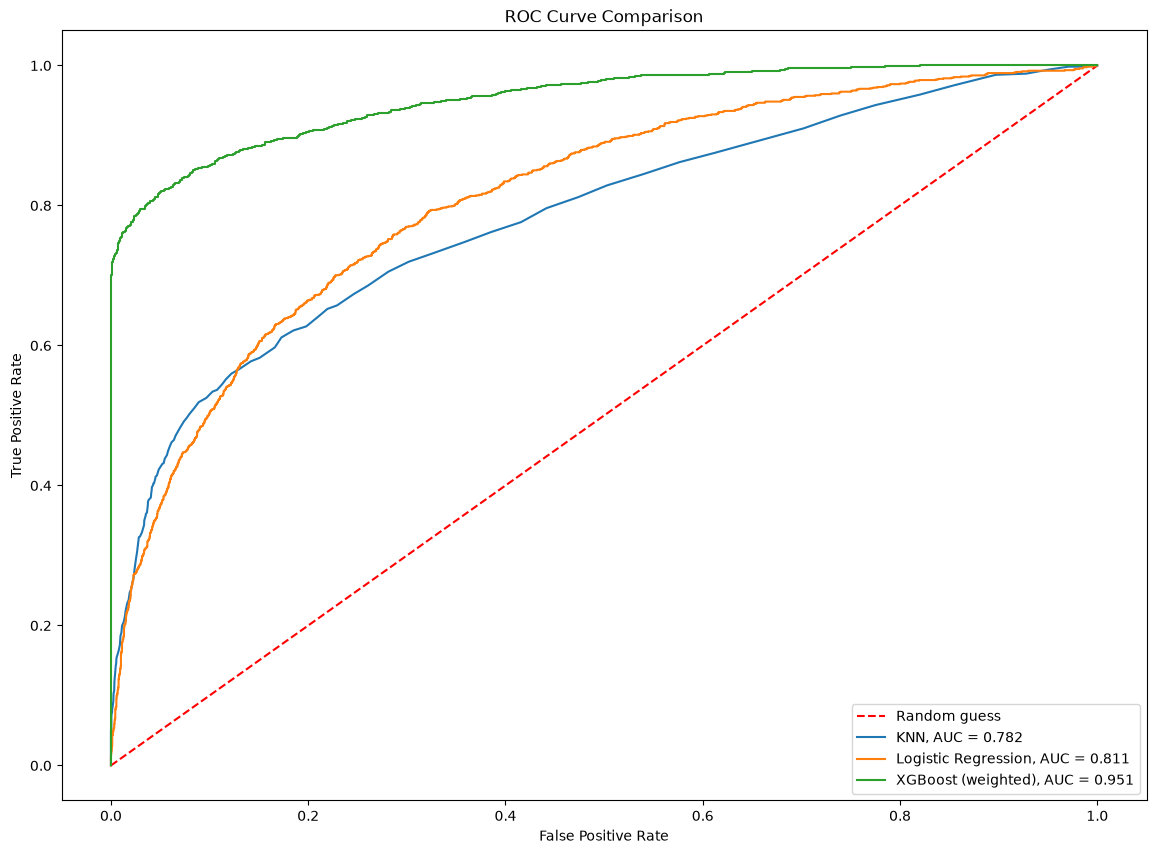

In [91]:
from sklearn import metrics
from sklearn.metrics import roc_auc_score

# --- Weighted XGBoost (replaces plain XGBoost as your best model) ---
scale = (y_train == 0).sum() / (y_train == 1).sum()
xgb_weighted = XGBClassifier(n_estimators=1000, learning_rate=0.05, scale_pos_weight=scale)
xgb_weighted.fit(x_train, y_train)

fig = plt.figure(figsize=(14, 10))
plt.plot([0, 1], [0, 1], 'r--', label='Random guess')

# KNN
probsknn = knn.predict_proba(x_test)[:, 1]
fpr, tpr, _ = metrics.roc_curve(y_test, probsknn)
aucknn = roc_auc_score(y_test, probsknn)
plt.plot(fpr, tpr, label=f'KNN, AUC = {round(aucknn, 3)}')

# Logistic Regression
probslg = lg.predict_proba(x_test)[:, 1]
fpr, tpr, _ = metrics.roc_curve(y_test, probslg)
auclg = roc_auc_score(y_test, probslg)
plt.plot(fpr, tpr, label=f'Logistic Regression, AUC = {round(auclg, 3)}')

# XGBoost (weighted)
probsxgb = xgb_weighted.predict_proba(x_test)[:, 1]
fpr, tpr, _ = metrics.roc_curve(y_test, probsxgb)
aucxgb = roc_auc_score(y_test, probsxgb)
plt.plot(fpr, tpr, label=f'XGBoost (weighted), AUC = {round(aucxgb, 3)}')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.show()

## ROC-AUC Model Comparison
The ROC curve evaluates ranking across all classification thresholds. Weighted XGBoost has the strongest AUC at 0.951, compared with 0.811 for logistic regression and 0.782 for KNN, indicating the best separation between defaults and non-defaults.

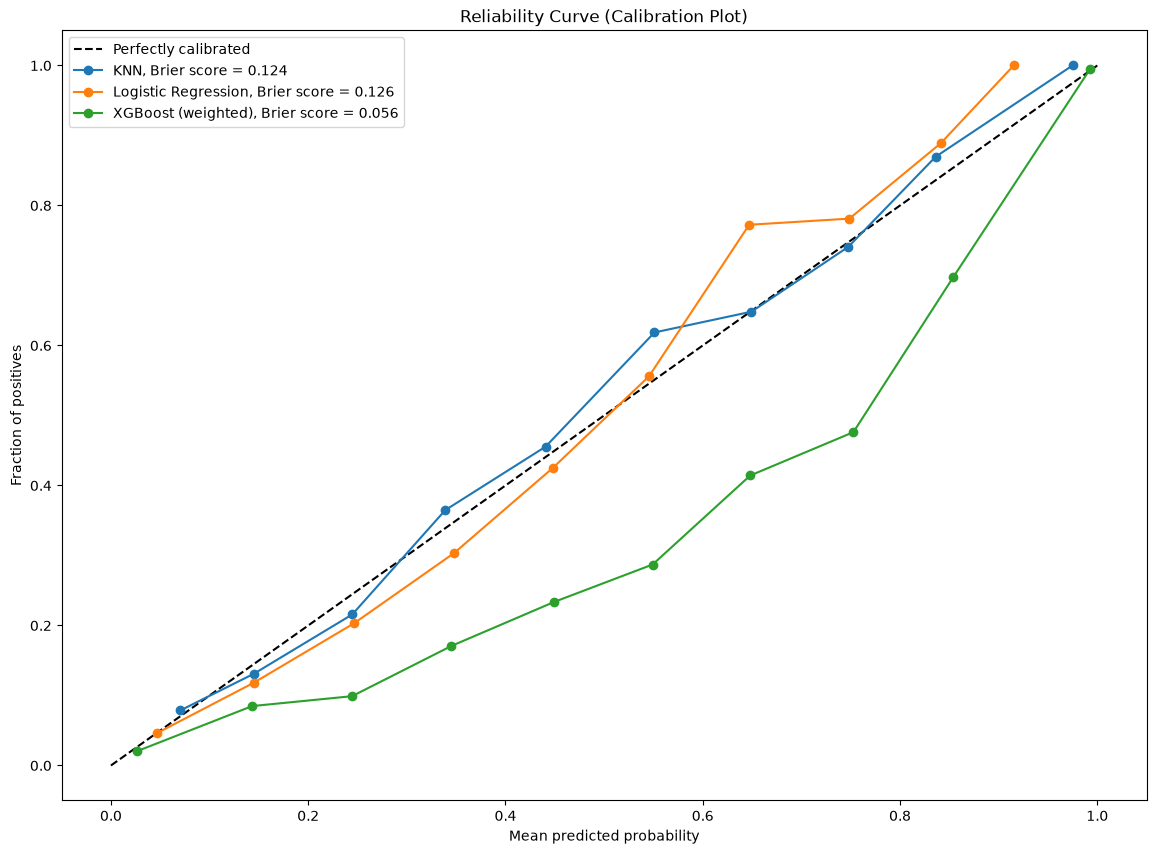

In [95]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

fig = plt.figure(figsize=(14, 10))
plt.plot([0, 1], [0, 1], color="black", linestyle='--', label='Perfectly calibrated')

# KNN
preds_proba_knn = knn.predict_proba(x_test)
knn_y, knn_x = calibration_curve(y_test, preds_proba_knn[:,1], n_bins=10)
loss_knn = brier_score_loss(y_test, preds_proba_knn[:, 1])
plt.plot(knn_x, knn_y, marker='o', label=f'KNN, Brier score = {round(loss_knn, 3)}')

# Logistic Regression
preds_proba_lg = lg.predict_proba(x_test)
lg_y, lg_x = calibration_curve(y_test, preds_proba_lg[:, 1], n_bins=10)
loss_lg = brier_score_loss(y_test, preds_proba_lg[:, 1])
plt.plot(lg_x, lg_y, marker='o', label=f'Logistic Regression, Brier score = {round(loss_lg, 3)}')

# XGBoost (weighted)
preds_proba_xgb = xgb_weighted.predict_proba(x_test)
xgb_y, xgb_x = calibration_curve(y_test, preds_proba_xgb[:, 1], n_bins=10)
loss_xgb = brier_score_loss(y_test, preds_proba_xgb[:, 1])
plt.plot(xgb_x, xgb_y, marker='o', label=f'XGBoost (weighted), Brier score = {round(loss_xgb, 3)}')

plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Reliability Curve (Calibration Plot)')
plt.legend(loc='upper left')
plt.show()

## Calibration and Brier Score
The weighted XGBoost reliability curve has the lowest Brier score, 0.056, versus 0.124 for KNN and 0.126 for logistic regression. Lower error means its predicted default probabilities are closer to observed outcomes, which is valuable for risk-based decisions rather than only yes/no classification.

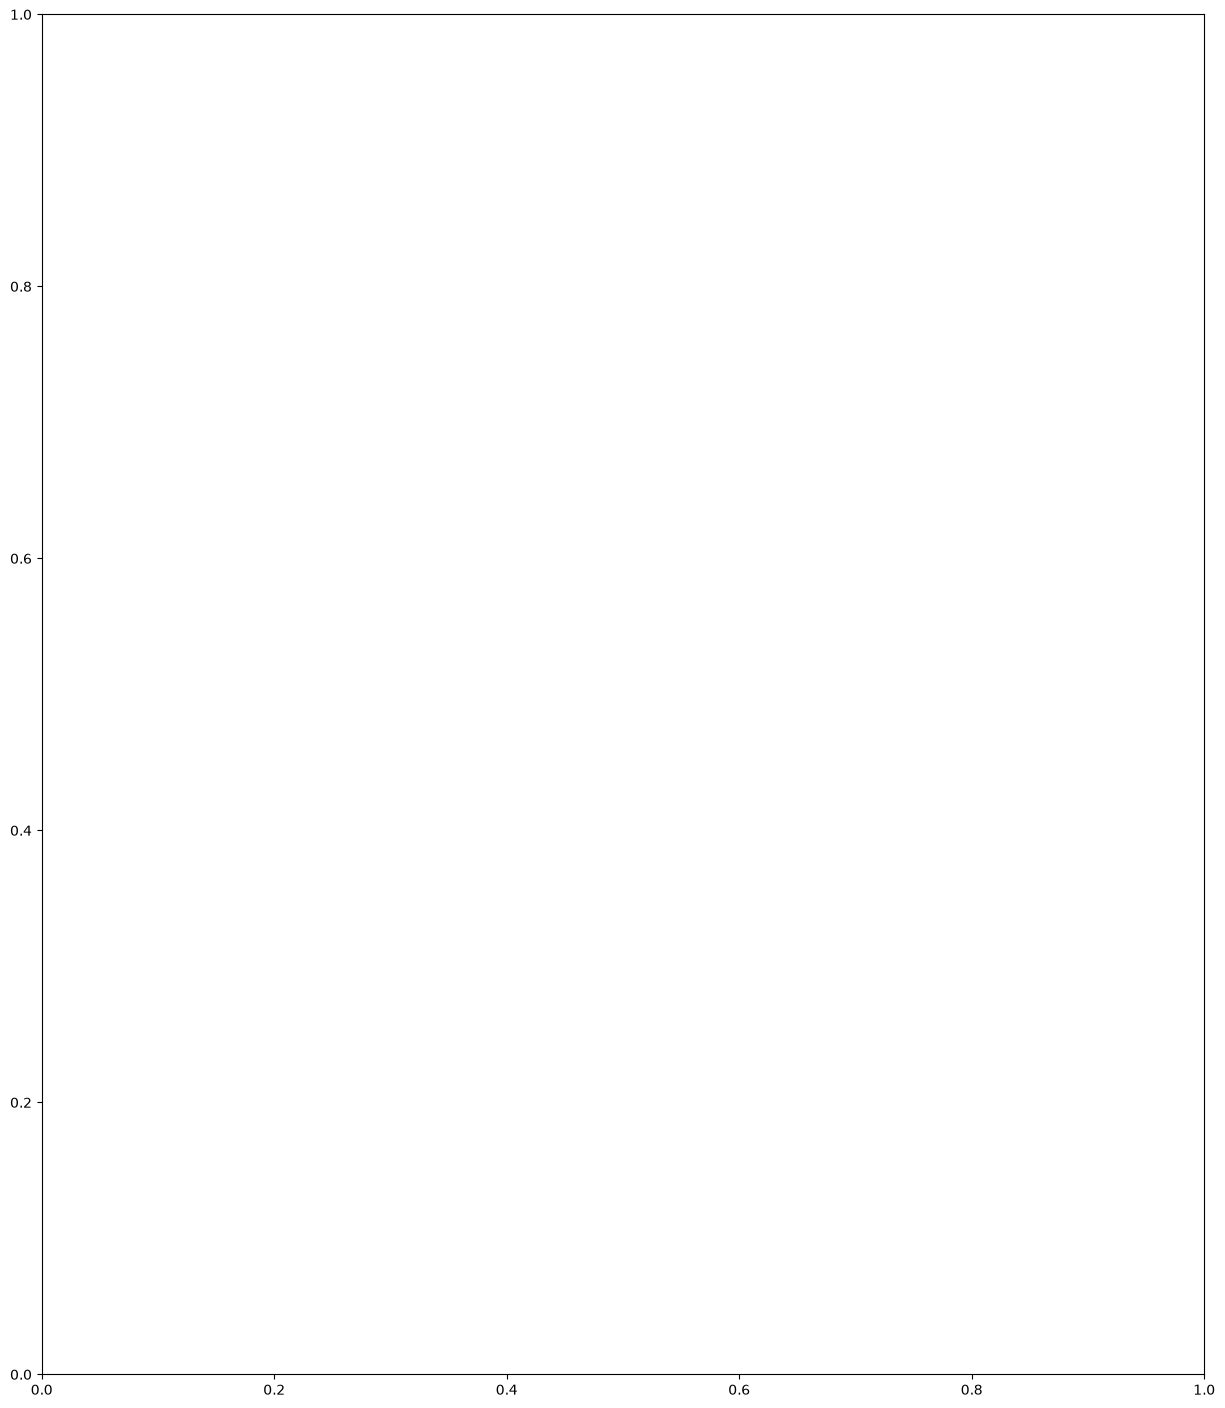

In [102]:
#Feature importance plot
fig, (ax1) = plt.subplots(figsize = (15, 17), ncols=1, nrows=1)
plt.subplots_adjust(left=0.125, right=0.9, bottom=0.1, top = 0.9, wspace=0, hspace = 0.5)

## Prepare the Feature-Importance Figure
This cell creates the plotting area for explaining which encoded borrower and loan features contribute most to the XGBoost model's predictions.

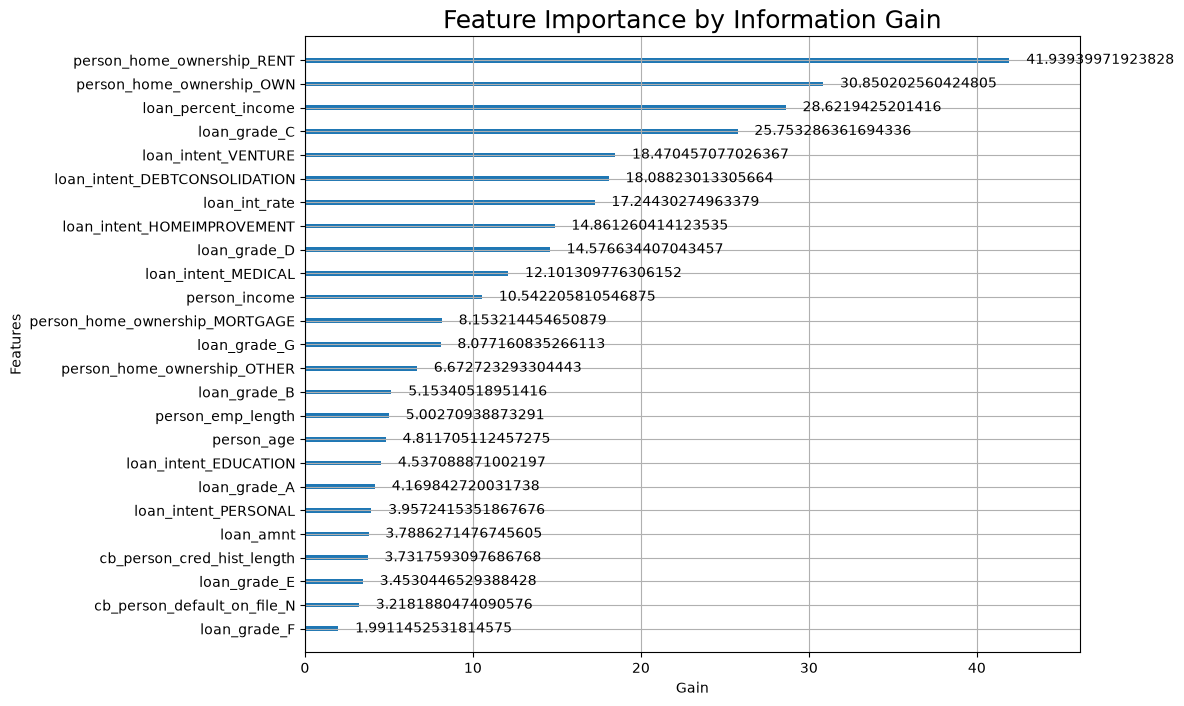

In [104]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 8))
plot_importance(xgb, importance_type='gain', ax=ax1)
ax1.set_title('Feature Importance by Information Gain', fontsize=18)
ax1.set_xlabel('Gain')
plt.show()

## Feature Importance by Information Gain
The leading features are `person_home_ownership_RENT` (gain 41.94), `person_home_ownership_OWN` (30.85), `loan_percent_income` (28.62), and `loan_grade_C` (25.75). These values describe predictive contribution within this fitted model, not causal effects or evidence that a feature should be used without fairness and policy review.

## Conclusion
This analysis supports weighted XGBoost as the strongest candidate among the tested models: it combines high default recall and F1 with ROC-AUC 0.951 and Brier score 0.056. Before production use, validate performance with cross-validation and out-of-time data, calibrate or retune the operating threshold against lending costs, and audit feature use for fairness and regulatory compliance.

Reference: [A Machine Learning Approach To Credit Risk Assessment](https://towardsdatascience.com/a-machine-learning-approach-to-credit-risk-assessment-ba8eda1cd11f/).

In [110]:
import pickle
import os

# Create artifacts folder if it does not already exist
os.makedirs('artifacts', exist_ok=True)

# Save trained weighted XGBoost model
with open('artifacts/xgb_weighted_model.pkl', 'wb') as f:
    pickle.dump(xgb_weighted, f)

# Save exact feature column order
with open('artifacts/feature_columns.pkl', 'wb') as f:
    pickle.dump(list(x_train.columns), f)

## Save Model Artifacts
The trained weighted XGBoost model is saved for later inference, while the feature-column list preserves the exact input order used during training. Keeping both artifacts prevents deployment predictions from being generated with missing, reordered, or mismatched features.

In [111]:
print(list(x_train.columns))

['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_A', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F', 'loan_grade_G', 'cb_person_default_on_file_N', 'cb_person_default_on_file_Y']
